<a href="https://colab.research.google.com/github/mujtaba-mohiyuddin/ucb-traffic-sign-recognition/blob/main/UCB_20260830_Practical_Application_MNIST_Digit_Classification_SVM_approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## Import and Load  MNIST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf  # only used here to conveniently load the MNIST dataset

(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train_full.shape)
print("Training labels shape:", y_train_full.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


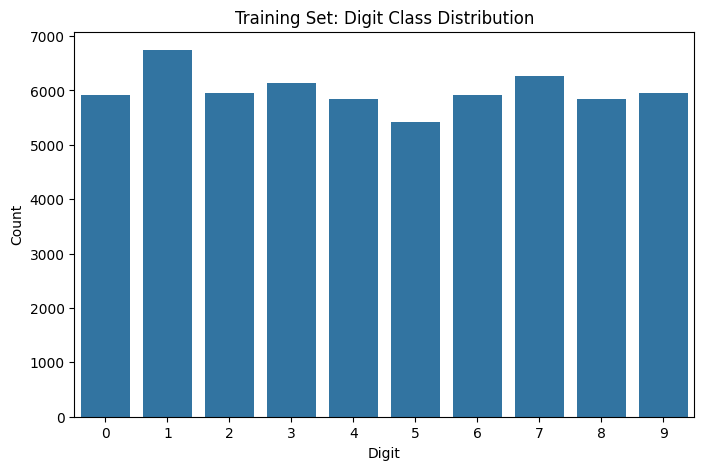

Digit 0: 5923 images (9.9%)
Digit 1: 6742 images (11.2%)
Digit 2: 5958 images (9.9%)
Digit 3: 6131 images (10.2%)
Digit 4: 5842 images (9.7%)
Digit 5: 5421 images (9.0%)
Digit 6: 5918 images (9.9%)
Digit 7: 6265 images (10.4%)
Digit 8: 5851 images (9.8%)
Digit 9: 5949 images (9.9%)


In [2]:
## EDA : Class Distribution

plt.figure(figsize=(8,5))
sns.countplot(x=y_train_full)
plt.title("Training Set: Digit Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

unique, counts = np.unique(y_train_full, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images ({count/len(y_train_full)*100:.1f}%)")

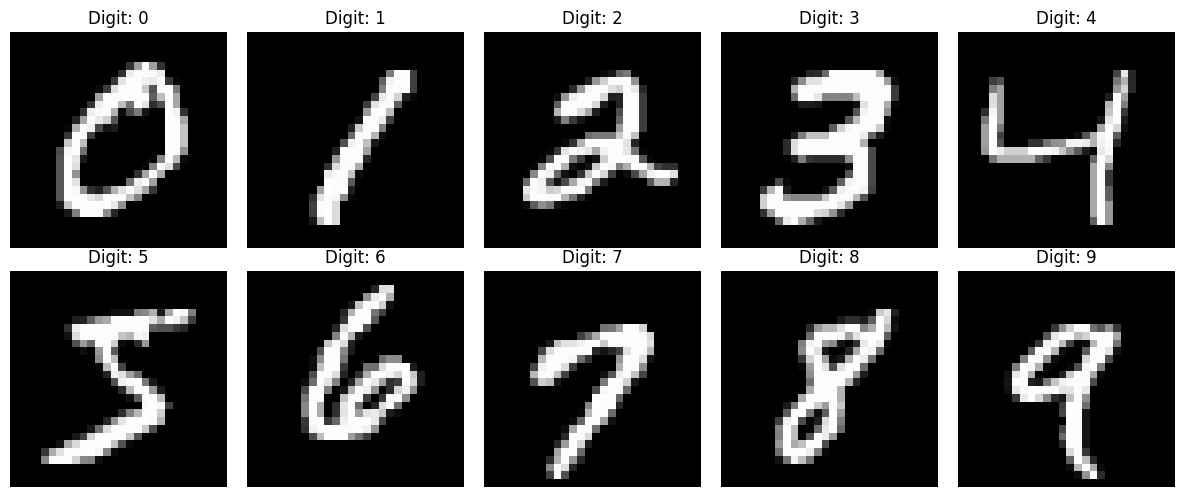

In [3]:
## EDA: Sample Digit Grid

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
## Preprocessing: Normalize & Flatten

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# SVM needs flat feature vectors, not 2D images
X_train_full_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_full_flat.shape)
print("Flattened test shape:", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)


In [7]:
## Subsample for Training Speed  (for SVM)

# SVMs scale poorly with dataset size. Using the full 60,000 images with an
# RBF kernel can take a very long time in Colab. We'll train on a
# representative subsample instead - a common, reasonable practice for SVM
# experimentation, and still gives a robust estimate of performance.

SAMPLE_SIZE = 10000  # adjust up/down depending on how much time you have

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_full_flat, y_train_full,
    train_size=SAMPLE_SIZE, random_state=42, stratify=y_train_full
)

print("Training sample shape:", X_train_sample.shape)

Training sample shape: (10000, 784)


In [8]:
## Train/Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_sample, y_train_sample, test_size=0.1, random_state=42, stratify=y_train_sample
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test_flat.shape)

Train: (9000, 784) Val: (1000, 784) Test: (10000, 784)


In [9]:
## Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_flat)

In [10]:
# Train SVM

svm_model = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
print("SVM training complete")

SVM training complete


In [11]:
## Validation Accuracy

val_accuracy = svm_model.score(X_val_scaled, y_val)
print(f"SVM Validation Accuracy: {val_accuracy:.4f}")

SVM Validation Accuracy: 0.9500


In [12]:
## Evaluate on Test Set

y_pred = svm_model.predict(X_test_scaled)
test_accuracy = (y_pred == y_test).mean()

print(f"SVM Test Accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_pred))

SVM Test Accuracy: 0.9473
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.93      0.93      0.93      1032
           3       0.94      0.95      0.94      1010
           4       0.96      0.94      0.95       982
           5       0.96      0.93      0.94       892
           6       0.96      0.95      0.96       958
           7       0.88      0.94      0.91      1028
           8       0.95      0.92      0.94       974
           9       0.95      0.92      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



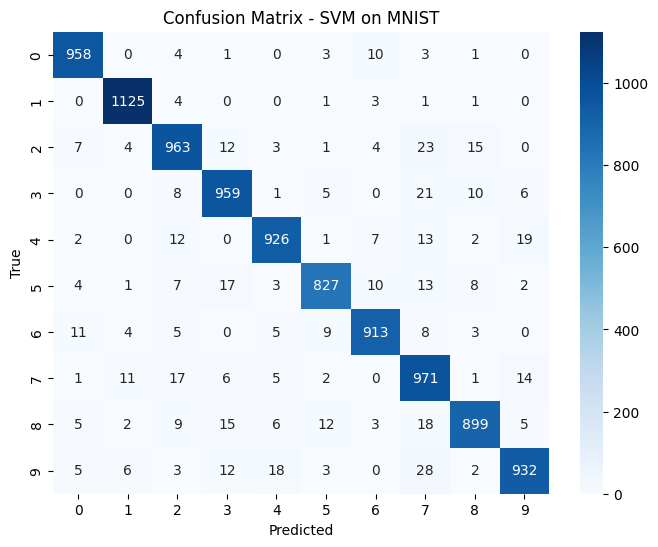

In [13]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM on MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

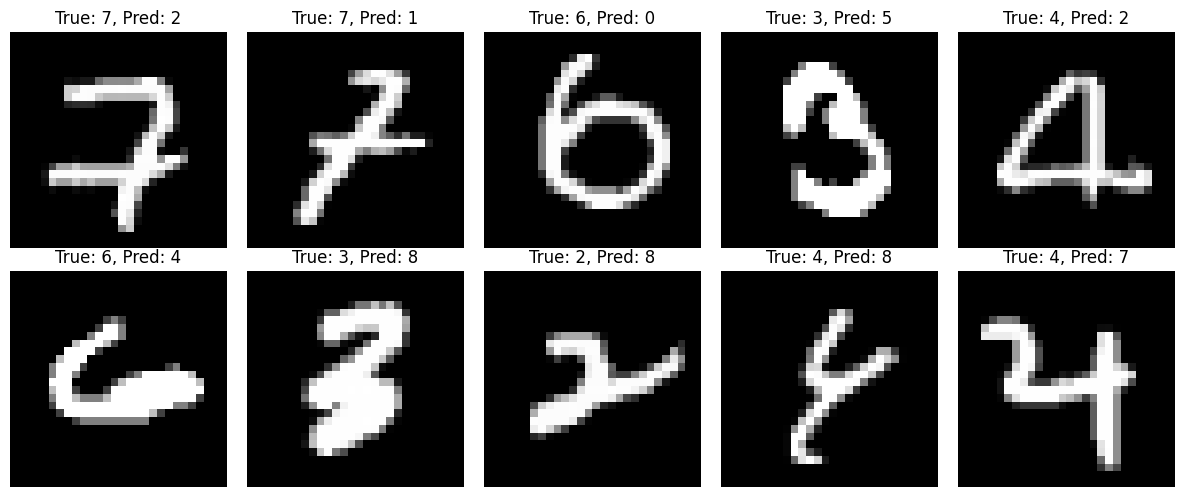

Total misclassified: 527 out of 10000 (5.27%)


In [14]:
## Visualize Misclassified Digits

misclassified_idx = np.where(y_pred != y_test)[0]
sample_idx = np.random.choice(misclassified_idx, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

kernel=linear: Validation Accuracy=0.9130
kernel=rbf: Validation Accuracy=0.9500
kernel=poly: Validation Accuracy=0.9440


/tmp/ipykernel_6010/3209496091.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="kernel", y="val_accuracy", data=results_df, palette="Blues_d")


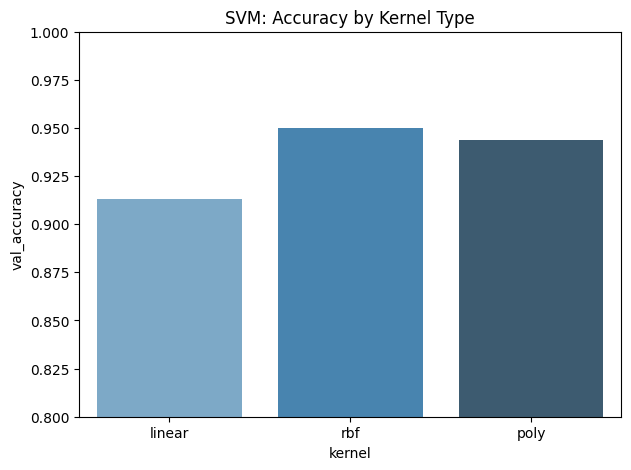

In [15]:
## Trying different Kernels for Comparison

kernels = ["linear", "rbf", "poly"]
results = []

for k in kernels:
    model = SVC(kernel=k, C=5, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_val_scaled, y_val)
    results.append({"kernel": k, "val_accuracy": acc})
    print(f"kernel={k}: Validation Accuracy={acc:.4f}")

results_df = pd.DataFrame(results)
plt.figure(figsize=(7,5))
sns.barplot(x="kernel", y="val_accuracy", data=results_df, palette="Blues_d")
plt.title("SVM: Accuracy by Kernel Type")
plt.ylim(0.8, 1.0)
plt.show()